LINEAR REGRESSION

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

le = LabelEncoder()

train['Activity'] = le.fit_transform(train['Activity'])
test['Activity'] = le.transform(test['Activity'])

X_train = train.drop('Activity', axis=1)
X_test = test.drop('Activity', axis=1)

y_train = train['Activity']
y_test = test['Activity']

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9489087596854254


MULTIPLE LINEAR REGRESSION

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

le = LabelEncoder()

train['Activity'] = le.fit_transform(train['Activity'])
test['Activity'] = le.transform(test['Activity'])
X_train = train.drop('Activity', axis=1)
X_test = test.drop('Activity', axis=1)

y_train = train['Activity']
y_test = test['Activity']

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9489087596854254
MSE: 0.14871955881611365


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    '/content/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
Predicted Per Capita Income in 2020:
41288.69409441762


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


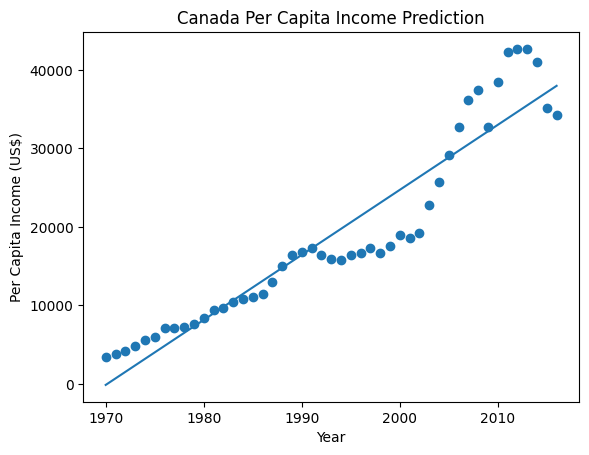

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/canada_per_capita_income.csv")

print(df.head())

X = df[['year']]

y = df['per capita income (US$)']

model = LinearRegression()

model.fit(X, y)

prediction = model.predict([[2020]])

print("Predicted Per Capita Income in 2020:")
print(prediction[0])

plt.scatter(df['year'], df['per capita income (US$)'])

plt.plot(df['year'], model.predict(X))

plt.xlabel("Year")
plt.ylabel("Per Capita Income (US$)")
plt.title("Canada Per Capita Income Prediction")

plt.show()

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("/content/canada_per_capita_income.csv")

df['year_square'] = df['year'] ** 2
df['year_cube'] = df['year'] ** 3

X = df[['year', 'year_square', 'year_cube']]
y = df['per capita income (US$)']

model = LinearRegression()

model.fit(X, y)

prediction = model.predict([[2020, 2020**2, 2020**3]])

print("Predicted Income in 2020:")
print(prediction[0])

y_pred = model.predict(X)

print("R2 Score:")
print(r2_score(y, y_pred))

print("Coefficients:")
print(model.coef_)

print("Intercept:")
print(model.intercept_)

Predicted Income in 2020:
50352.915472984314
R2 Score:
0.92948814978257
Coefficients:
[ 1.45148940e+06 -7.42036944e+02  1.26471792e-01]
Intercept:
-946582793.5949022


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
